# Welcome to PointNet& 3D CNNs Workshop!
In this workshop, we're going to learn how to voxelize a point cloud, and build a 3D Convolutional Neural Network to classify point clouds. When processing point clouds, voxel based approaches account for a good half of the existing approaches (with point based approaches being the second half) — and it's therefore important to understand how to implement them!

## Imports

In [11]:
import torch
torch.cuda.is_available()


True

In [12]:
!pip -q install numpy matplotlib plotly tqdm


In [13]:
#global var
FEATURE_MODE = "xyz"   # options: "xyz", "xy", "yz"


In [14]:
import os

# Check if the directory already exists to avoid unzipping multiple times
if not os.path.exists('/content/PointNet'):
    !unzip -q /content/PointNet.zip -d /content/
    print("File unzipped successfully to /content/PointNet")
else:
    print("Directory /content/PointNet already exists, skipping unzip.")

Directory /content/PointNet already exists, skipping unzip.


In [15]:
import os, sys, glob

# where your unzipped folder is
BASE_DIR = "/content/PointNet"

# dataset folder (this replaces Kaggle's /kaggle/input/shapenet-core-seg/...)
DATA_FOLDER = os.path.join(BASE_DIR, "shapenet-core-seg", "Shapenetcore_benchmark")

# ---- find and add lidar scripts path ----
# your notebook currently has:
# sys.path.append('/kaggle/input/lidar-od-scripts/gpuVersion/gpuVersion/')
#
# In Colab, the exact internal structure may differ, so we locate it safely:
candidates = glob.glob(os.path.join(BASE_DIR, "lidar-od-scripts", "**", "gpuVersion"), recursive=True)

print("DATA_FOLDER =", DATA_FOLDER)
print("Found gpuVersion candidates:", candidates[:5])

# pick a reasonable scripts folder:
# if you see ".../gpuVersion/gpuVersion", that's usually the one you want
scripts_path = None
for c in candidates:
    c2 = os.path.join(c, "gpuVersion")
    if os.path.isdir(c2):
        scripts_path = c2
        break

if scripts_path is None:
    # fallback: just add lidar-od-scripts root
    scripts_path = os.path.join(BASE_DIR, "lidar-od-scripts")

print("Using scripts_path =", scripts_path)
sys.path.append(scripts_path)

# quick sanity checks
assert os.path.isdir(DATA_FOLDER), "DATA_FOLDER not found. Check your zip folder structure."
print("✅ Base setup looks good.")


DATA_FOLDER = /content/PointNet/shapenet-core-seg/Shapenetcore_benchmark
Found gpuVersion candidates: ['/content/PointNet/lidar-od-scripts/gpuVersion', '/content/PointNet/lidar-od-scripts/gpuVersion/gpuVersion']
Using scripts_path = /content/PointNet/lidar-od-scripts/gpuVersion/gpuVersion
✅ Base setup looks good.


In [16]:
# Usual Imports
import os
import sys
import json
import numpy as np
from tqdm import tqdm

# plotting library
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# append path to custom scripts

# DL Imports
import torch
import torch.nn as nn

# custom imports
from visual_utils import plot_pc_data3d, plot_bboxes_3d

In [17]:

class_name_id_map = {'Airplane': 0, 'Bag': 1, 'Cap': 2, 'Car': 3, 'Chair': 4,
                'Earphone': 5, 'Guitar': 6, 'Knife': 7, 'Lamp': 8, 'Laptop': 9,
                'Motorbike': 10, 'Mug': 11, 'Pistol': 12, 'Rocket': 13,
                'Skateboard': 14, 'Table': 15}

class_id_name_map = {v:k for k,v in class_name_id_map.items()}

PCD_SCENE=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False), aspectmode='data')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Shapenet Core Dataset exploration

- Object Classification and part Segmentation Dataset from Point Cloud data
- [Shapenet core](https://shapenet.org/) is a subset of the full ShapeNet dataset
- It contains single clean 3D models, manually verified category and alignment annotations.
- 16 classes from 12 categories

In [18]:
train_split_data = json.load(open(os.path.join(DATA_FOLDER, "train_split.json"), "r"))
train_class_count = np.array([x[0] for x in train_split_data])

# plot classwise count in train set
train_dist_plots = [go.Bar(x=list(class_name_id_map.keys()), y= np.bincount(train_class_count))]
layout = dict(template="plotly_dark", title="Shapenet Core Train Distribution", title_x=0.5)
fig = go.Figure(data=train_dist_plots, layout=layout)
fig.show()

In [19]:
import glob
points_list = glob.glob(os.path.join(DATA_FOLDER, "04379243", "points", "*.npy"))
print(len(points_list))

5263


In [20]:
import random
idx = random.randint(0,len(points_list))

# load point cloud data
points = np.load(points_list[idx])
print(f"points shape = {points.shape}, min xyz = {np.min(points, axis=0)}, max xyz = {np.max(points, axis=0)}")

# load segmentation lables
seg_file_path = points_list[idx].replace('points', 'points_label').replace('.npy', '.seg')
seg_labels = np.loadtxt(seg_file_path).astype(np.int8)
print(f"seg_labels shape = {seg_labels.shape}, unique labels = {np.unique(seg_labels)}")

points shape = (2797, 3), min xyz = [-0.2879  -0.28868 -0.2875 ], max xyz = [0.28807 0.28868 0.28861]
seg_labels shape = (2797,), unique labels = [1 2]


In [21]:
# there are max of 16 parts in an object in Shapenet core dataset
# creating random colors in according to part label
NUM_PARTS = 16
PART_COLORS = np.random.choice(range(255),size=(NUM_PARTS,3))

In [22]:
pc_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, color=PART_COLORS[seg_labels - 1], marker_size=2)
layout = dict(template="plotly_dark", title="Raw Point cloud", scene=PCD_SCENE, title_x=0.5)
fig = go.Figure(data=pc_plots, layout=layout)
fig.show()

## Build a Custom Dataset
Now that we've explored our data, we'll get more 'PyTorch friendly' and create a Dataset object, as well as a PyTorch Dataloader.

In [54]:
#my helper function :D
import numpy as np

def voxel_downsample(points: np.ndarray, voxel_size: float) -> np.ndarray:
    """
    points: (N, 3) float array
    voxel_size: size of each voxel cell
    returns: (M, 3) downsampled points
    """
    if voxel_size <= 0:
        return points

    # 1) translate to positive coordinates
    min_xyz = points.min(axis=0)
    shifted = points - min_xyz

    # 2) grid / voxel indices
    vox = np.floor(shifted / voxel_size).astype(np.int32)

    # 3) keep one point per occupied voxel
    _, unique_idx = np.unique(vox, axis=0, return_index=True)
    down = shifted[unique_idx]

    # 4) translate back
    down = down + min_xyz
    return down

def random_rotation_matrix(rng: np.random.RandomState) -> np.ndarray:
    """Uniform-ish random 3D rotation using random axis + angle."""
    axis = rng.normal(size=3).astype(np.float32)
    axis /= (np.linalg.norm(axis) + 1e-8)
    angle = rng.uniform(0, 2*np.pi)

    x, y, z = axis
    c = np.cos(angle); s = np.sin(angle); C = 1 - c

    R = np.array([
        [c + x*x*C,     x*y*C - z*s, x*z*C + y*s],
        [y*x*C + z*s,   c + y*y*C,   y*z*C - x*s],
        [z*x*C - y*s,   z*y*C + x*s, c + z*z*C  ]
    ], dtype=np.float32)
    return R

def perspective_project_random_dim(points: np.ndarray,
                                   rng: np.random.RandomState,
                                   depth_scale: float = 2.0) -> np.ndarray:
    """
    Pick a random depth dimension d in {0,1,2}.
    Apply perspective scaling to the other two coordinates based on depth,
    and set the depth coordinate to 0 (so the model still gets Nx3).
    """
    d = int(rng.randint(0, 3))
    depth = points[:, d]

    # Keep denominator positive-ish; add shift to avoid blowups
    denom = 1.0 + (depth / depth_scale)
    denom = np.clip(denom, 0.2, 5.0)  # prevents extreme scaling

    out = points.copy()
    for j in range(3):
        if j != d:
            out[:, j] = out[:, j] / denom
    out[:, d] = 0.0
    return out

In [24]:
import os, sys

# Root of your unzipped PointNet folder in Colab
BASE_DIR = "/content/PointNet"

# ShapeNet benchmark folder
DATA_FOLDER = os.path.join(BASE_DIR, "shapenet-core-seg", "Shapenetcore_benchmark")

print("BASE_DIR:", BASE_DIR)
print("DATA_FOLDER:", DATA_FOLDER)
print("Exists?", os.path.isdir(DATA_FOLDER))

assert os.path.isdir(DATA_FOLDER), "DATA_FOLDER not found – check zip structure"


BASE_DIR: /content/PointNet
DATA_FOLDER: /content/PointNet/shapenet-core-seg/Shapenetcore_benchmark
Exists? True


In [55]:
#I changed this class to fit the task2 requirments
import torch

class ShapeNetDatasetSubset(torch.utils.data.Dataset):
    def __init__(
        self,
        root_dir: str,
        split_type: str,
        allowed_class_names: list[str],
        max_per_class: int = 120,
        num_samples: int = 2048,
        voxel_size: float = 0.02,
        seed: int = 0
    ):
        self.root_dir = root_dir
        self.split_type = split_type
        self.num_samples = num_samples
        self.voxel_size = voxel_size
        self.seed = seed
        rng = np.random.RandomState(seed)

        # Load split list
        with open(os.path.join(root_dir, f"{split_type}_split.json"), "r") as f:
            split_data = json.load(f)

        # Filter only allowed classes
        split_data = [row for row in split_data if row[1] in allowed_class_names]

        # Limit to max_per_class per category (balanced subset)
        per_class = {name: [] for name in allowed_class_names}
        for row in split_data:
            per_class[row[1]].append(row)

        subset = []
        for name in allowed_class_names:
            items = per_class[name]
            rng.shuffle(items)
            subset.extend(items[:max_per_class])

        # Shuffle final subset
        rng.shuffle(subset)
        self.split_data = subset

    def __len__(self):
        return len(self.split_data)

    def __getitem__(self, index: int):
        class_id, class_name, point_cloud_path, seg_label_path = self.split_data[index]

        pc_path = os.path.join(self.root_dir, point_cloud_path)
        points = np.load(pc_path).astype(np.float32)  # (N, 3)

        seg_path = os.path.join(self.root_dir, seg_label_path)
        seg_labels = np.loadtxt(seg_path).astype(np.int64) - 1  # shift to 0-based

        # --- voxel downsampling (assignment requirement) ---
        points_ds = voxel_downsample(points, self.voxel_size)

        # sample/duplicate to fixed num_samples
        n = points_ds.shape[0]
        if n >= self.num_samples:
            idx = np.random.choice(n, self.num_samples, replace=False)
        else:
            idx = np.random.choice(n, self.num_samples, replace=True)

        points_final = points_ds[idx]
        # ---- Feature dropping / projection experiments ----
        # Use stable randomness per (seed, index) so results are reproducible
        rng_local = np.random.RandomState(self.seed * 1000003 + index)

        if FEATURE_MODE == "xy":
            points_final = points_final.copy()
            points_final[:, 2] = 0.0  # drop z

        elif FEATURE_MODE == "yz":
            points_final = points_final.copy()
            points_final[:, 0] = 0.0  # drop x

        elif FEATURE_MODE == "proj":   # <--- NEW: rotation + perspective projection
            points_final = points_final.copy()

            # 1) random rotation
            R = random_rotation_matrix(rng_local)
            points_final = points_final @ R.T

            # 2) perspective projection on a random dimension
            points_final = perspective_project_random_dim(points_final, rng_local, depth_scale=2.0)

        # ---- Feature dropping experiment ----
        if FEATURE_MODE == "xy":
          points_final = points_final.copy()
          points_final[:, 2] = 0.0  # drop z
        elif FEATURE_MODE == "yz":
          points_final = points_final.copy()
          points_final[:, 0] = 0.0  # drop x
        # IMPORTANT: seg labels correspond to original points; after voxel downsample we lost alignment.
        # The simplest acceptable approach for classification-only runs is to ignore seg_labels downstream,
        # but if your notebook uses seg_labels for segmentation, tell me and we’ll adapt properly.
        seg_final = seg_labels[np.minimum(idx, seg_labels.shape[0]-1)]

        return {
                "class_id": class_id,
                "class_name": class_name,
                "points": points_final,
                "seg_labels": seg_final
        }

In [26]:
# new code datasets and printing the counts
selected_classes = ["Airplane", "Car", "Chair", "Lamp", "Table", "Pistol"]
MAX_PER_CLASS = 120
VOXEL_SIZE = 0.02
NUM_SAMPLES = 2048

train_set = ShapeNetDatasetSubset(DATA_FOLDER, "train", selected_classes,
                                  max_per_class=MAX_PER_CLASS,
                                  num_samples=NUM_SAMPLES,
                                  voxel_size=VOXEL_SIZE,
                                  seed=0)

val_set = ShapeNetDatasetSubset(DATA_FOLDER, "val", selected_classes,
                                max_per_class=max(30, MAX_PER_CLASS // 4),
                                num_samples=NUM_SAMPLES,
                                voxel_size=VOXEL_SIZE,
                                seed=1)

test_set = ShapeNetDatasetSubset(DATA_FOLDER, "test", selected_classes,
                                 max_per_class=max(30, MAX_PER_CLASS // 4),
                                 num_samples=NUM_SAMPLES,
                                 voxel_size=VOXEL_SIZE,
                                 seed=2)

print("Selected classes:", selected_classes)
print("Train size:", len(train_set))
print("Val size:", len(val_set))
print("Test size:", len(test_set))

# Show per-class counts (train)
from collections import Counter
train_counts = Counter([train_set.split_data[i][1] for i in range(len(train_set))])
print("Train counts per class:", dict(train_counts))


Selected classes: ['Airplane', 'Car', 'Chair', 'Lamp', 'Table', 'Pistol']
Train size: 720
Val size: 175
Test size: 180
Train counts per class: {'Chair': 120, 'Lamp': 120, 'Car': 120, 'Airplane': 120, 'Pistol': 120, 'Table': 120}


In [27]:
import numpy as np, os

raw = np.load(os.path.join(DATA_FOLDER, train_set.split_data[0][2])).astype(np.float32)
down = voxel_downsample(raw, VOXEL_SIZE)

print("Raw points:", raw.shape[0])
print("After voxel downsampling:", down.shape[0])
print("Reduction ratio:", down.shape[0] / raw.shape[0])


Raw points: 2769
After voxel downsampling: 1932
Reduction ratio: 0.6977248104008668


### Data loader for Custom dataset

In [28]:
def collate_fn(batch_list):
    ret = {}
    ret['class_id'] =  torch.from_numpy(np.array([x['class_id'] for x in batch_list])).long()
    ret['class_name'] = np.array([x['class_name'] for x in batch_list])
    ret['points'] = torch.from_numpy(np.stack([x['points'] for x in batch_list], axis=0)).float()
    ret['seg_labels'] = torch.from_numpy(np.stack([x['seg_labels'] for x in batch_list], axis=0)).long()
    return ret

In [29]:
sample_loader = torch.utils.data.DataLoader(train_set, batch_size=16, num_workers=2, shuffle=True, collate_fn=collate_fn)
dataloader_iter = iter(sample_loader)
batch_dict = next(dataloader_iter)
print(batch_dict.keys())
for key in ['points','seg_labels', 'class_id']:
    print(f"batch_dict[{key}].shape = {batch_dict[key].shape}")

dict_keys(['class_id', 'class_name', 'points', 'seg_labels'])
batch_dict[points].shape = torch.Size([16, 2048, 3])
batch_dict[seg_labels].shape = torch.Size([16, 2048])
batch_dict[class_id].shape = torch.Size([16])


In [30]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64
WORKERS = 2

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS)

In [31]:
batch = next(iter(train_loader))
print(type(batch))
print(batch.keys() if hasattr(batch, "keys") else "no keys")
if hasattr(batch, "keys"):
    print({k: (v.shape if hasattr(v, "shape") else type(v)) for k,v in batch.items()})


<class 'dict'>
dict_keys(['class_id', 'class_name', 'points', 'seg_labels'])
{'class_id': torch.Size([64]), 'class_name': <class 'list'>, 'points': torch.Size([64, 2048, 3]), 'seg_labels': torch.Size([64, 2048])}


# PointNet

**The model is PointNet.**<p>
![PointNet](https://d3i71xaburhd42.cloudfront.net/c3b6a072288e134f5ae6afe3eebc970ffb65cb68/3-Figure2-1.png)

It's coming from the paper: https://arxiv.org/pdf/1612.00593.pdf

The Point-Net will be done in several parts:
* T-Net
* FeatureNet
* Classification or Segmentation Head

### T-Net

In [32]:
import torch.nn.functional as F
from torch.autograd import Variable

class STN3d(nn.Module):
    """
    T-Net Model.
    STN stands for Spatial Transformer Network.
    """
    def __init__(self, num_points = 2500):
        super(STN3d, self).__init__()
        self.num_points = num_points
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)

        self.mp1 = torch.nn.MaxPool1d(num_points)

        # FC layers
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 9)
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)


    def forward(self, x):
        batchsize = x.size()[0]

        # Expected input shape = (bs, 3, num_points)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.mp1(x)
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        iden = Variable(torch.from_numpy(np.array([1,0,0,0,1,0,0,0,1]).astype(np.float32))).view(1,9).repeat(batchsize,1)
        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, 3, 3)
        return x

In [33]:
test_model = STN3d().to(device)
sim_data = Variable(torch.rand(32,3,2500)).to(device)
out = test_model(sim_data)
print('stn', out.size())

stn torch.Size([32, 3, 3])


## FeatureNet

In [34]:
class PointNetfeat(nn.Module):
    """
    This is the T-Net for Feature Transform.
    There is also MLP part 64,128,1024.
    """
    def __init__(self, num_points = 2500, global_feat = True):
        super(PointNetfeat, self).__init__()
        self.stn = STN3d(num_points = num_points)
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.mp1 = torch.nn.MaxPool1d(num_points)
        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        batchsize = x.size()[0]
        trans = self.stn(x)
        x = x.transpose(2,1)
        x = torch.bmm(x, trans)
        x = x.transpose(2,1)
        x = F.relu(self.bn1(self.conv1(x)))
        pointfeat = x
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        x = self.mp1(x)
        x = x.view(-1, 1024)
        if self.global_feat:
            return x, trans
        else:
            x = x.view(-1, 1024, 1).repeat(1, 1, self.num_points)
            return torch.cat([x, pointfeat], 1), trans

In [35]:
pointfeat = PointNetfeat(global_feat=True).to(device)
out, _ = pointfeat(sim_data)
print('global feat', out.size())

pointfeat = PointNetfeat(global_feat=False).to(device)
out, _ = pointfeat(sim_data)
print('point feat', out.size())

global feat torch.Size([32, 1024])
point feat torch.Size([32, 1088, 2500])


## Classifier Head

In [36]:
class PointNetCls(nn.Module):
    """
    Network for Classification: 512, 256, K.
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetCls, self).__init__()
        self.num_points = num_points
        self.feat = PointNetfeat(num_points, global_feat=True)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
    def forward(self, x):
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return F.log_softmax(x, dim=-1), trans

In [37]:
cls = PointNetCls(k = 16).to(device)
out, _ = cls(sim_data)
print('class', out.size())

class torch.Size([32, 16])


In [38]:
#new classes to help
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointNetfeatAvgPool(nn.Module):
    """
    Same as PointNetfeat but uses AvgPool instead of MaxPool.
    """
    def __init__(self, num_points=2500, global_feat=True):
        super(PointNetfeatAvgPool, self).__init__()
        self.stn = STN3d(num_points=num_points)
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

        # change is here
        self.pool = torch.nn.AvgPool1d(num_points)

        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        batchsize = x.size()[0]
        trans = self.stn(x)

        x = x.transpose(2, 1)
        x = torch.bmm(x, trans)
        x = x.transpose(2, 1)

        x = F.relu(self.bn1(self.conv1(x)))
        pointfeat = x
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))

        x = self.pool(x)
        x = x.view(-1, 1024)

        if self.global_feat:
            return x, trans
        else:
            x = x.view(-1, 1024, 1).repeat(1, 1, self.num_points)
            return torch.cat([x, pointfeat], 1), trans


class PointNetClsAvgPool(nn.Module):
    """
    Same as PointNetCls but uses the AvgPool feature extractor.
    """
    def __init__(self, num_points=2500, k=2):
        super(PointNetClsAvgPool, self).__init__()
        self.num_points = num_points
        self.feat = PointNetfeatAvgPool(num_points, global_feat=True)

        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)

    def forward(self, x):
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return F.log_softmax(x, dim=-1), trans


## Training

In [39]:
def train_model(model, num_epochs, criterion, optimizer, dataloader_train,
                label_str = 'class_id', lr_scheduler = None, output_name = 'pointnet.pth'):
    # move model to device
    model.to(device)

    for epoch in range(num_epochs):
        print(f"Starting {epoch + 1} epoch ...")

        # Training
        model.train()
        train_loss = 0.0
        for batch_dict in tqdm(dataloader_train, total=len(dataloader_train)):
            # Forward pass
            x = batch_dict['points'].transpose(1, 2).to(device)
            labels = batch_dict[label_str].to(device)
            pred, _ = model(x)
            loss = criterion(pred, labels)
            train_loss += loss.item()

            # Backward pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # adjust learning rate
            if lr_scheduler is not None:
                lr_scheduler.step()

        # compute per batch losses, metric value
        train_loss = train_loss / len(dataloader_train)

        print(f'Epoch: {epoch+1}, trainLoss:{train_loss:6.5f}')
    torch.save(model.state_dict(), output_name)

In [40]:
#not needed to run

import torch.optim as optim

N_EPOCHS = 20
num_points = 2048
num_classes = 16
criterion = nn.NLLLoss()

# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
classifier = PointNetCls(k = num_classes, num_points = num_points)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.9)
if torch.cuda.is_available():
    classifier.cuda()


_ = train_model(classifier, N_EPOCHS, criterion, optimizer, train_loader)

Starting 1 epoch ...


100%|██████████| 11/11 [00:03<00:00,  2.98it/s]


Epoch: 1, trainLoss:1.03461
Starting 2 epoch ...


100%|██████████| 11/11 [00:03<00:00,  3.55it/s]


Epoch: 2, trainLoss:0.09444
Starting 3 epoch ...


...

Epoch: 18, trainLoss:0.00166
Starting 19 epoch ...


100%|██████████| 11/11 [00:03<00:00,  3.40it/s]


Epoch: 19, trainLoss:0.00150
Starting 20 epoch ...


100%|██████████| 11/11 [00:04<00:00,  2.67it/s]

Epoch: 20, trainLoss:0.00101


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Inference

In [42]:
classifier = PointNetCls(num_points=NUM_SAMPLES, k=num_classes).to(device)
classifier.load_state_dict(torch.load('pointnet.pth'))
classifier.eval()

total_loss = 0.0

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['class_id'].to(device)
        pred, _ = classifier(x)

        # calculate loss
        loss = criterion(pred, labels)
        total_loss += loss.item()

evaluation_loss = total_loss / len(test_loader)
print(evaluation_loss)

100%|██████████| 3/3 [00:01<00:00,  2.27it/s]

0.06518983965118726


## Test on individual items

In [43]:
# Random test sample
test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
batch_dict = collate_fn([test_sample])
x = batch_dict['points'].transpose(1, 2).to(device)

# Get model predictions
model_preds, _ = classifier(x)
predicted_class = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]
predicted_class_name = class_id_name_map[predicted_class]
pred_class_probs = F.softmax(model_preds.flatten(), dim=None).detach().cpu().numpy()

# plot results
title = f"Label = {test_sample['class_name']}, Predicted class = {predicted_class_name}"
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {}]], column_widths=[0.4, 0.6])
fig.update_layout(template="plotly_dark", scene=PCD_SCENE, height = 400, width = 1200,
                title=title, title_x=0.1, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))
fig.add_trace(plot_pc_data3d(x=test_sample['points'][:,0], y=test_sample['points'][:,1], z=test_sample['points'][:,2]), row=1, col=1)
fig.add_trace(go.Bar(x=list(class_name_id_map.keys()), y=pred_class_probs, showlegend=False), row=1, col=2)
fig.show()

/tmp/ipython-input-3837583052.py:10: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



## Segmentation

In [44]:
class PointNetDenseCls(nn.Module):
    """
    Network for Segmentation
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetDenseCls, self).__init__()
        self.num_points = num_points
        self.k = k
        self.feat = PointNetfeat(num_points, global_feat=False)
        self.conv1 = torch.nn.Conv1d(1088, 512, 1)
        self.conv2 = torch.nn.Conv1d(512, 256, 1)
        self.conv3 = torch.nn.Conv1d(256, 128, 1)
        self.conv4 = torch.nn.Conv1d(128, self.k, 1)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)

    def forward(self, x):
        batchsize = x.size()[0]
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.conv4(x)
        return x, trans

In [45]:
seg = PointNetDenseCls(k = 16).to(device)
print(seg)
out, _ = seg(sim_data)
print('seg', out.size())

PointNetDenseCls(
  (feat): PointNetfeat(
    (stn): STN3d(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (mp1): MaxPool1d(kernel_size=2500, stride=2500, padding=0, dilation=1, ceil_mode=False)
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (relu): ReLU()
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True

## Training segmentation model

In [46]:
#not needed to run

N_EPOCHS = 20
num_points = 2048
criterion = nn.CrossEntropyLoss()

# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
dense_classifier = PointNetDenseCls(k = NUM_PARTS, num_points = num_points)
dense_classifier.to(device)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(dense_classifier.parameters(), lr=0.01, momentum=0.9)

train_model(dense_classifier, N_EPOCHS, criterion, optimizer, train_loader,
            label_str='seg_labels', output_name='pointnet_seg.pth')

Starting 1 epoch ...


100%|██████████| 11/11 [00:05<00:00,  2.01it/s]


Epoch: 1, trainLoss:1.99751
Starting 2 epoch ...


100%|██████████| 11/11 [00:05<00:00,  2.14it/s]


Epoch: 2, trainLoss:1.12113
Starting 3 epoch ...


...

Epoch: 18, trainLoss:0.90508
Starting 19 epoch ...


100%|██████████| 11/11 [00:05<00:00,  1.97it/s]


Epoch: 19, trainLoss:0.90425
Starting 20 epoch ...


100%|██████████| 11/11 [00:07<00:00,  1.39it/s]


Epoch: 20, trainLoss:0.89836


## Inference

In [47]:
dense_classifier.load_state_dict(torch.load('pointnet_seg.pth'))
dense_classifier.eval()

total_loss = 0.0

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['seg_labels'].to(device)
        pred, _ = dense_classifier(x)

        # calculate loss
        loss = criterion(pred, labels)
        total_loss += loss.item()

evaluation_loss = total_loss / len(test_loader)
print(evaluation_loss)

100%|██████████| 3/3 [00:01<00:00,  1.95it/s]

0.9992239276568095


## Test on individual items

In [48]:
# Random test sample
test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
batch_dict = collate_fn([test_sample])

# Get model predictions
x = batch_dict['points'].transpose(1, 2).to(device)
model_preds, _ = dense_classifier(x)
pred_part_labels = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]

points = test_sample['points']
part_labels = test_sample['seg_labels']


# plot results
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}]], column_widths=[0.5, 0.5],
                    subplot_titles=('Part Labels', 'Part Predictions'))

# ground truth part labels
part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False,
                                  color=PART_COLORS[part_labels - 1], marker_size=2)

# ground truth part labels
pred_part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False,
                                  color=PART_COLORS[pred_part_labels - 1], marker_size=2)

fig.update_layout(template="plotly_dark", scene=PCD_SCENE, scene2=PCD_SCENE, height = 400, width = 1200,
                title='PointNet Segmentation', title_x=0.5, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))
fig.add_trace(part_label_plots, row=1, col=1)
fig.add_trace(pred_part_label_plots, row=1, col=2)
fig.show()

In [49]:
import torch, os

torch.save(classifier.state_dict(), "pointnet_baseline_xyz.pth")
print("Saved:", os.path.isfile("pointnet_baseline_xyz.pth"))


Saved: True


In [50]:
#not needed to run

import torch

@torch.no_grad()
def eval_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    for batch in loader:
        pts = batch["points"].to(device)             # (B, N, 3)
        labels = batch["class_id"].to(device).long() # (B,)

        out = model(pts.transpose(1, 2))             # (B, 3, N)

        # Handle different forward() return formats:
        # out may be (logits, trans_feat) OR (logits, trans, trans_feat)
        if isinstance(out, (tuple, list)):
            logits = out[0]
        else:
            logits = out

        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.numel()

    return correct / total

val_acc = eval_accuracy(classifier, val_loader, device)
test_acc = eval_accuracy(classifier, test_loader, device)
print(f"Baseline (xyz) Val Acc:  {val_acc:.4f}")
print(f"Baseline (xyz) Test Acc: {test_acc:.4f}")


Baseline (xyz) Val Acc:  0.9943
Baseline (xyz) Test Acc: 0.9889


In [58]:
#not needed to run
def train_and_eval(feature_mode, epochs=10, lr=0.001):
    global FEATURE_MODE
    FEATURE_MODE = feature_mode

    model = PointNetCls(num_points=NUM_SAMPLES, k=num_classes).to(device)
    criterion = torch.nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    _ = train_model(model, epochs, criterion, optimizer, train_loader)

    va = eval_accuracy(model, val_loader, device)
    ta = eval_accuracy(model, test_loader, device)

    return model, va, ta

results_31 = {}
for mode in ["xy", "yz", "proj"]:
    proj_model, va, ta = train_and_eval(mode, epochs=10)
    results_31[mode] = (va, ta)
    print(f"{mode}: Val Acc={va:.4f}, Test Acc={ta:.4f}")

FEATURE_MODE = "xyz"


Starting 1 epoch ...


100%|██████████| 11/11 [00:04<00:00,  2.70it/s]


Epoch: 1, trainLoss:0.64657
Starting 2 epoch ...


100%|██████████| 11/11 [00:03<00:00,  2.85it/s]


Epoch: 2, trainLoss:0.18066
Starting 3 epoch ...


...

100%|██████████| 11/11 [00:04<00:00,  2.72it/s]


Epoch: 9, trainLoss:0.04462
Starting 10 epoch ...


100%|██████████| 11/11 [00:03<00:00,  2.85it/s]

Epoch: 10, trainLoss:0.01836


proj: Val Acc=1.0000, Test Acc=0.9722


In [52]:
#not needed to run
avg_model = PointNetClsAvgPool(num_points=NUM_SAMPLES, k=num_classes).to(device)
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(avg_model.parameters(), lr=0.001)

_ = train_model(avg_model, 20, criterion, optimizer, train_loader)

avg_val = eval_accuracy(avg_model, val_loader, device)
avg_test = eval_accuracy(avg_model, test_loader, device)
print(f"AvgPool (xyz) Val Acc:  {avg_val:.4f}")
print(f"AvgPool (xyz) Test Acc: {avg_test:.4f}")

torch.save(avg_model.state_dict(), "pointnet_avgpool_xyz.pth")
print("Saved:", __import__("os").path.isfile("pointnet_avgpool_xyz.pth"))


Starting 1 epoch ...


100%|██████████| 11/11 [00:03<00:00,  2.93it/s]


Epoch: 1, trainLoss:0.96568
Starting 2 epoch ...


100%|██████████| 11/11 [00:03<00:00,  2.82it/s]


Epoch: 2, trainLoss:0.14203
Starting 3 epoch ...


...

100%|██████████| 11/11 [00:04<00:00,  2.75it/s]


Epoch: 19, trainLoss:0.05479
Starting 20 epoch ...


100%|██████████| 11/11 [00:03<00:00,  3.53it/s]

Epoch: 20, trainLoss:0.02126


AvgPool (xyz) Val Acc:  0.9714
AvgPool (xyz) Test Acc: 0.9500
Saved: True


# **Task 2, all Parts:**

In [59]:
import os, numpy as np, torch
from torch.utils.data import DataLoader

# ---------- settings ----------
selected_classes = ["Airplane", "Car", "Chair", "Lamp", "Table", "Pistol"]
MAX_PER_CLASS = 120
VOXEL_SIZE = 0.02
NUM_SAMPLES = 2048

BATCH_SIZE = 64
WORKERS = 2
LR = 1e-3

BASELINE_EPOCHS = 20
FEATURE_EPOCHS  = 10
AVGPOOL_EPOCHS  = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- label remap (adapter, no class edits) ----------
CLASS_TO_IDX = {name: i for i, name in enumerate(selected_classes)}
print("CLASS_TO_IDX:", CLASS_TO_IDX)

class RemapLabelsWrapper(torch.utils.data.Dataset):
    def __init__(self, base_ds, class_to_idx):
        self.base_ds = base_ds
        self.class_to_idx = class_to_idx
    def __len__(self):
        return len(self.base_ds)
    def __getitem__(self, i):
        item = self.base_ds[i]
        # Force labels to 0..5 based on class_name
        item["class_id"] = self.class_to_idx[item["class_name"]]
        return item

# ---------- build datasets (uses your existing ShapeNetDatasetSubset) ----------
train_base = ShapeNetDatasetSubset(DATA_FOLDER, "train", selected_classes,
                                   max_per_class=MAX_PER_CLASS,
                                   num_samples=NUM_SAMPLES,
                                   voxel_size=VOXEL_SIZE,
                                   seed=0)
val_base = ShapeNetDatasetSubset(DATA_FOLDER, "val", selected_classes,
                                 max_per_class=max(30, MAX_PER_CLASS // 4),
                                 num_samples=NUM_SAMPLES,
                                 voxel_size=VOXEL_SIZE,
                                 seed=1)
test_base = ShapeNetDatasetSubset(DATA_FOLDER, "test", selected_classes,
                                  max_per_class=max(30, MAX_PER_CLASS // 4),
                                  num_samples=NUM_SAMPLES,
                                  voxel_size=VOXEL_SIZE,
                                  seed=2)

train_set = RemapLabelsWrapper(train_base, CLASS_TO_IDX)
val_set   = RemapLabelsWrapper(val_base, CLASS_TO_IDX)
test_set  = RemapLabelsWrapper(test_base, CLASS_TO_IDX)

# ---------- dataset proof prints ----------
from collections import Counter
train_counts = Counter([train_base.split_data[i][1] for i in range(len(train_base))])
print("\nSelected classes:", selected_classes)
print("Train size:", len(train_set))
print("Val size:", len(val_set))
print("Test size:", len(test_set))
print("Train counts per class:", dict(train_counts))

raw = np.load(os.path.join(DATA_FOLDER, train_base.split_data[0][2])).astype(np.float32)
down = voxel_downsample(raw, VOXEL_SIZE)
print("Raw points:", raw.shape[0])
print("After voxel downsampling:", down.shape[0])
print("Reduction ratio:", down.shape[0] / raw.shape[0])

# ---------- loaders ----------
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS)

# sanity check labels BEFORE any training (prevents CUDA assert)
b = next(iter(train_loader))
labels = b["class_id"]
print("\nLabel min/max:", labels.min().item(), labels.max().item())
print("Unique labels:", sorted(labels.unique().tolist()))
assert labels.min().item() >= 0 and labels.max().item() < len(selected_classes)

num_classes = len(selected_classes)

# ---------- robust eval (doesn't assume model returns 3 values) ----------
@torch.no_grad()
def eval_accuracy_any(model, loader):
    model.eval()
    correct = 0
    total = 0
    for batch in loader:
        pts = batch["points"].to(device)
        y = batch["class_id"].to(device).long()
        out = model(pts.transpose(1,2))
        logits = out[0] if isinstance(out, (tuple, list)) else out
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

# ---------- Baseline (xyz + MaxPool) ----------
print("\n=== Baseline: MaxPool, xyz ===")
classifier = PointNetCls(num_points=NUM_SAMPLES, k=num_classes).to(device)
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
_ = train_model(classifier, BASELINE_EPOCHS, criterion, optimizer, train_loader)

base_val = eval_accuracy_any(classifier, val_loader)
base_test = eval_accuracy_any(classifier, test_loader)
print(f"Baseline (xyz) Val Acc:  {base_val:.4f}")
print(f"Baseline (xyz) Test Acc: {base_test:.4f}")
torch.save(classifier.state_dict(), "pointnet_baseline_xyz.pth")

# ---------- Task 3.1 (Feature dropping) ----------
# Uses your existing FEATURE_MODE mechanism if you added it earlier.
# If you didn't, this section will be skipped safely.
def has_feature_mode():
    return "FEATURE_MODE" in globals()

def train_and_eval_feature(mode, epochs=FEATURE_EPOCHS):
    global FEATURE_MODE
    FEATURE_MODE = mode
    m = PointNetCls(num_points=NUM_SAMPLES, k=num_classes).to(device)
    c = torch.nn.NLLLoss()
    o = torch.optim.Adam(m.parameters(), lr=LR)
    _ = train_model(m, epochs, c, o, train_loader)
    return eval_accuracy_any(m, val_loader), eval_accuracy_any(m, test_loader)

xy_val = xy_test = yz_val = yz_test = None
if has_feature_mode():
    print("\n=== Task 3.1: Feature dropping ===")
    xy_val, xy_test = train_and_eval_feature("xy")
    print(f"xy (z=0): Val Acc={xy_val:.4f}, Test Acc={xy_test:.4f}")
    yz_val, yz_test = train_and_eval_feature("yz")
    print(f"yz (x=0): Val Acc={yz_val:.4f}, Test Acc={yz_test:.4f}")
    FEATURE_MODE = "xyz"
else:
    print("\n[Skip] FEATURE_MODE not found in notebook; Task 3.1 requires the small FEATURE_MODE patch in dataset __getitem__.")

# ---------- Task 3.2 (AvgPool) ----------
print("\n=== Task 3.2: AvgPool (xyz) ===")
import torch.nn as nn
import torch.nn.functional as F

class PointNetfeatAvgPool(nn.Module):
    def __init__(self, num_points=2500, global_feat=True):
        super().__init__()
        self.stn = STN3d(num_points=num_points)
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.pool = nn.AvgPool1d(num_points)
        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        trans = self.stn(x)
        x = x.transpose(2,1)
        x = torch.bmm(x, trans)
        x = x.transpose(2,1)
        x = F.relu(self.bn1(self.conv1(x)))
        pointfeat = x
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        x = self.pool(x)
        x = x.view(-1, 1024)
        return (x, trans) if self.global_feat else (torch.cat([x.view(-1,1024,1).repeat(1,1,self.num_points), pointfeat], 1), trans)

class PointNetClsAvgPool(nn.Module):
    def __init__(self, num_points=2500, k=2):
        super().__init__()
        self.feat = PointNetfeatAvgPool(num_points, global_feat=True)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)

    def forward(self, x):
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return F.log_softmax(x, dim=-1), trans

avg_model = PointNetClsAvgPool(num_points=NUM_SAMPLES, k=num_classes).to(device)
avg_crit = torch.nn.NLLLoss()
avg_opt = torch.optim.Adam(avg_model.parameters(), lr=LR)
_ = train_model(avg_model, AVGPOOL_EPOCHS, avg_crit, avg_opt, train_loader)

avg_val = eval_accuracy_any(avg_model, val_loader)
avg_test = eval_accuracy_any(avg_model, test_loader)
print(f"AvgPool (xyz) Val Acc:  {avg_val:.4f}")
print(f"AvgPool (xyz) Test Acc: {avg_test:.4f}")
torch.save(avg_model.state_dict(), "pointnet_avgpool_xyz.pth")

# ---------- summary ----------
print("\n=========== SUMMARY ===========")
print(f"Baseline MaxPool xyz: Val {base_val:.4f} | Test {base_test:.4f}")
if xy_val is not None:
    print(f"Feature drop xy:      Val {xy_val:.4f} | Test {xy_test:.4f}")
    print(f"Feature drop yz:      Val {yz_val:.4f} | Test {yz_test:.4f}")
print(f"Architecture AvgPool: Val {avg_val:.4f} | Test {avg_test:.4f}")
print("================================")


Using device: cuda
CLASS_TO_IDX: {'Airplane': 0, 'Car': 1, 'Chair': 2, 'Lamp': 3, 'Table': 4, 'Pistol': 5}

Selected classes: ['Airplane', 'Car', 'Chair', 'Lamp', 'Table', 'Pistol']
Train size: 720
Val size: 175
Test size: 180
Train counts per class: {'Chair': 120, 'Lamp': 120, 'Car': 120, 'Airplane': 120, 'Pistol': 120, 'Table': 120}
Raw points: 2769
After voxel downsampling: 1932
Reduction ratio: 0.6977248104008668

Label min/max: 0 5
Unique labels: [0, 1, 2, 3, 4, 5]

=== Baseline: MaxPool, xyz ===
Starting 1 epoch ...


100%|██████████| 11/11 [00:03<00:00,  3.17it/s]


Epoch: 1, trainLoss:0.69047
Starting 2 epoch ...


100%|██████████| 11/11 [00:04<00:00,  2.46it/s]


Epoch: 2, trainLoss:0.10954
Starting 3 epoch ...


...

100%|██████████| 11/11 [00:03<00:00,  3.01it/s]


Epoch: 19, trainLoss:0.00872
Starting 20 epoch ...


100%|██████████| 11/11 [00:03<00:00,  3.09it/s]

Epoch: 20, trainLoss:0.00623


AvgPool (xyz) Val Acc:  0.9943
AvgPool (xyz) Test Acc: 0.9667

=========== SUMMARY ===========
Baseline MaxPool xyz: Val 0.9771 | Test 0.9833
Feature drop xy:      Val 0.9257 | Test 0.8667
Feature drop yz:      Val 0.9486 | Test 0.9500
Architecture AvgPool: Val 0.9943 | Test 0.9667


# **Visuals**

In [64]:
import numpy as np
import plotly.graph_objects as go

# A nice default 3D scene (feel free to tweak)
PCD_SCENE = dict(
    xaxis=dict(title="x", showgrid=False, zeroline=False),
    yaxis=dict(title="y", showgrid=False, zeroline=False),
    zaxis=dict(title="z", showgrid=False, zeroline=False),
    aspectmode="data",
)

def plot_pc_data3d(x, y, z,
                   apply_color_gradient=False,
                   color=None,
                   marker_size=2,
                   name="points"):
    """
    Returns a Plotly Scatter3d trace list (so it matches your `data=pc_plots` usage).
    - If `color` is a single color string: all points same color
    - If `color` is an array/list of per-point colors: used directly
    - If `apply_color_gradient=True`: colors by z value
    """
    x = np.asarray(x); y = np.asarray(y); z = np.asarray(z)

    marker = dict(size=marker_size, opacity=0.9)

    if apply_color_gradient:
        marker.update(color=z, colorscale="Viridis", showscale=True)
    else:
        if color is None:
            marker.update(color="white")
        else:
            marker.update(color=color)

    trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode="markers",
        marker=marker,
        name=name
    )
    return [trace]


In [65]:
# points: (N,3) numpy array
points = item["points"]  # or however you get it

pc_plots = plot_pc_data3d(
    x=points[:,0], y=points[:,1], z=points[:,2],
    apply_color_gradient=False,
    color="cyan",      # or per-point colors array
    marker_size=2
)

layout = dict(
    template="plotly_dark",
    title="Raw Point cloud",
    scene=PCD_SCENE,
    title_x=0.5
)

fig = go.Figure(data=pc_plots, layout=layout)
fig.show()


In [66]:
idx = 0
item = test_base[idx]
points = item["points"]

true_name = item["class_name"]
# pred_name = selected_classes[pred]  # if you computed pred

pc_plots = plot_pc_data3d(points[:,0], points[:,1], points[:,2],
                          apply_color_gradient=False,
                          color="orange",
                          marker_size=2)

fig = go.Figure(
    data=pc_plots,
    layout=dict(template="plotly_dark",
                title=f"Point Cloud | True: {true_name}",
                scene=PCD_SCENE,
                title_x=0.5)
)
fig.show()


In [67]:
# seg_labels: values 1..K (like in your snippet)
# PART_COLORS: list/np array of color strings of length K
color_per_point = np.array(PART_COLORS)[seg_labels - 1]

pc_plots = plot_pc_data3d(points[:,0], points[:,1], points[:,2],
                          apply_color_gradient=False,
                          color=color_per_point,
                          marker_size=2)

fig = go.Figure(
    data=pc_plots,
    layout=dict(template="plotly_dark",
                title="Colored by labels",
                scene=PCD_SCENE,
                title_x=0.5)
)
fig.show()


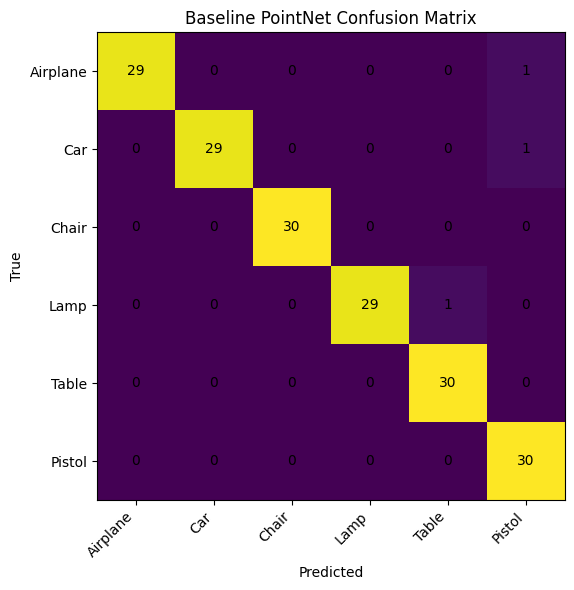

In [61]:
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def get_preds_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for batch in loader:
        pts = batch["points"].to(device)
        labels = batch["class_id"].to(device).long()
        out = model(pts.transpose(1, 2))
        logits = out[0] if isinstance(out, (tuple, list)) else out
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

def confusion_matrix(preds, labels, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for p, y in zip(preds, labels):
        cm[y, p] += 1
    return cm

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    # write counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

preds, labels = get_preds_labels(classifier, test_loader, device)  # baseline
cm = confusion_matrix(preds, labels, num_classes=len(selected_classes))
plot_confusion_matrix(cm, selected_classes, title="Baseline PointNet Confusion Matrix")


In [69]:
import numpy as np

@torch.no_grad()
def per_class_accuracy(model, loader, device, num_classes):
    model.eval()
    correct = np.zeros(num_classes)
    total = np.zeros(num_classes)

    for batch in loader:
        pts = batch["points"].to(device)
        labels = batch["class_id"].to(device).long()

        out = model(pts.transpose(1, 2))
        logits = out[0] if isinstance(out, (tuple, list)) else out
        preds = logits.argmax(dim=1)

        for c in range(num_classes):
            mask = (labels == c)
            correct[c] += (preds[mask] == c).sum().item()
            total[c] += mask.sum().item()

    acc = correct / (total + 1e-8)
    return acc
acc_per_class = per_class_accuracy(classifier, test_loader, device, len(selected_classes))

fig = go.Figure()
fig.add_bar(x=selected_classes, y=acc_per_class)
fig.update_layout(template="plotly_dark",
                  title="Per-Class Test Accuracy",
                  title_x=0.5,
                  yaxis_title="Accuracy")
fig.show()


In [71]:
import pandas as pd

df = pd.DataFrame({
    "Mode": list(results_31.keys()),
    "Val Accuracy": [v[0] for v in results_31.values()],
    "Test Accuracy": [v[1] for v in results_31.values()]
})

df

fig = go.Figure()
fig.add_bar(name="Validation", x=df["Mode"], y=df["Val Accuracy"])
fig.add_bar(name="Test", x=df["Mode"], y=df["Test Accuracy"])

fig.update_layout(
    barmode="group",
    template="plotly_dark",
    title="Feature Importance Comparison (Task 3.1)",
    title_x=0.5
)
fig.show()


In [72]:
@torch.no_grad()
def get_transformed_points(model, dataset, idx, device):
    item = dataset[idx]
    pts = torch.tensor(item["points"], dtype=torch.float32).unsqueeze(0).to(device)

    out = model(pts.transpose(1,2))
    logits, trans = out

    pts_np = item["points"]
    trans_np = trans[0].cpu().numpy()

    pts_trans = pts_np @ trans_np.T

    return pts_np, pts_trans
pts_orig, pts_trans = get_transformed_points(classifier, test_base, 0, device)

trace1 = plot_pc_data3d(pts_orig[:,0], pts_orig[:,1], pts_orig[:,2], color="cyan", marker_size=2)
trace2 = plot_pc_data3d(pts_trans[:,0], pts_trans[:,1], pts_trans[:,2], color="red", marker_size=2)

fig = go.Figure(data=trace1 + trace2,
                layout=dict(template="plotly_dark",
                            title="Original (cyan) vs T-Net Transformed (red)",
                            scene=PCD_SCENE,
                            title_x=0.5))
fig.show()
